1. IMPORT AND DRIVE MOUNT

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os, time, random, copy, math, json, shutil
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import h5py

Mounted at /content/drive


2. CONFIGURATION

In [2]:
CFG = {
    # ── Paths ─────────────────────────────────────────────────────────────────
    "DATA_ROOT"  : "/content/drive/MyDrive/MRI_Project/BraTS_dataset/BraTS2020_training_data/data",
    "SAVE_DIR"   : "/content/drive/MyDrive/MRI_Project/iPixMatch_Standalone_Checkpoints/",
    "BACKUP_DIR" : "/content/drive/MyDrive/MRI_Project/iPixMatch_Standalone_Backups/",

    # ── Data ──────────────────────────────────────────────────────────────────
    "LABELED_RATIO" : 0.10,       # same as Exp1
    "SKIP_EMPTY"    : 0.80,

    # ── Model ─────────────────────────────────────────────────────────────────
    "IN_CHANNELS"   : 4,
    "NUM_CLASSES"   : 3,
    "BASE_CHANNELS" : 32,
    "DROPOUT"       : 0.10,

    # ── Training ──────────────────────────────────────────────────────────────
    "EPOCHS"        : 30,
    "BATCH_SIZE"    : 4,
    "LR"            : 1e-4,
    "WEIGHT_DECAY"  : 1e-4,
    "NUM_WORKERS"   : 2,
    "SEED"          : 42,

    # ── UniMatch hyper-parameters ──────────────────────────────────────────────
    "CONF_THR"      : 0.40,
    "LAMBDA_U"      : 0.15,
    "EMA_ALPHA"     : 0.99,

    # ── iPixMatch additions ────────────────────────────────────────────────────
    "IPIX_ALPHA"    : 0.05,
    "IPIX_TEMP"     : 0.5,

    # ── Checkpointing ─────────────────────────────────────────────────────────
    "SAVE_EVERY"    : 2,
    "VAL_EVERY"     : 2,
}

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")
os.makedirs(CFG["SAVE_DIR"],   exist_ok=True)
os.makedirs(CFG["BACKUP_DIR"], exist_ok=True)


Device : cuda


3. SEEDING

In [3]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

set_seed(CFG["SEED"])

4. DATA UTILITIES

In [4]:
def load_h5(path):
    with h5py.File(path, 'r') as f:
        image = f['image'][:].astype(np.float32)
        mask  = f['mask'][:].astype(np.float32)
    image = np.transpose(image, (2, 0, 1))
    mask  = np.transpose(mask,  (2, 0, 1))
    return image, mask

def normalize_image(image):
    out = np.zeros_like(image, dtype=np.float32)
    for c in range(image.shape[0]):
        ch = image[c]; m = ch > 0
        if m.sum() == 0:
            out[c] = ch; continue
        mu, sigma = ch[m].mean(), ch[m].std() + 1e-8
        out[c] = (ch - mu) / sigma
    return out

def split_patients(root, labeled_ratio=0.10, seed=42):
    all_files = sorted([f for f in os.listdir(root) if f.endswith(".h5")])
    if len(all_files) == 0:
        raise ValueError(f"No .h5 files found in {root}")
    volumes = sorted(set([f.split("_slice_")[0] for f in all_files]))
    rng = random.Random(seed)
    rng.shuffle(volumes)
    val_n     = max(1, int(len(volumes) * 0.15))
    val       = volumes[:val_n]
    train     = volumes[val_n:]
    lab_n     = max(1, int(len(train) * labeled_ratio))
    labeled   = train[:lab_n]
    unlabeled = train[lab_n:]
    print(f"Volumes  total={len(volumes)}  labeled={len(labeled)}"
          f"  unlabeled={len(unlabeled)}  val={len(val)}")
    def get_files(vol_list):
        vol_set = set(vol_list)
        return [os.path.join(root, f) for f in all_files
                if f.split("_slice_")[0] in vol_set]
    return get_files(labeled), get_files(unlabeled), get_files(val)

def inf_loader(dl):
    while True:
        for b in dl: yield b

def permanent_save(src_dir, backup_dir):
    os.makedirs(backup_dir, exist_ok=True)
    count = 0
    for f in os.listdir(src_dir):
        if f.endswith(".pth"):
            shutil.copy2(os.path.join(src_dir, f),
                         os.path.join(backup_dir, f))
            count += 1
    print(f"  [BACKUP] {count} files → {backup_dir}")

5. AUGMENTATION

In [5]:
def weak_aug(img, lbl):
    if random.random() > 0.5:
        img = img[:, ::-1].copy(); lbl = lbl[:, ::-1].copy()
    return img, lbl

def strong_aug(img, lbl):
    if random.random() > 0.5:
        img = img[:, ::-1].copy(); lbl = lbl[:, ::-1].copy()
    if random.random() > 0.5:
        img = img[:, :, ::-1].copy(); lbl = lbl[:, :, ::-1].copy()
    k = random.randint(0, 3)
    if k:
        img = np.rot90(img, k, (1, 2)).copy()
        lbl = np.rot90(lbl, k, (1, 2)).copy()
    if random.random() > 0.5:
        img = img + np.random.normal(0, 0.05, img.shape).astype(np.float32)
    for c in range(img.shape[0]):
        if random.random() > 0.5:
            img[c] = img[c] * random.uniform(0.8, 1.2)
    return img, lbl

def cutmix(img1, lbl1, img2, lbl2, alpha=1.0):
    _, H, W = img1.shape
    lam = np.random.beta(alpha, alpha)
    cw = int(W * math.sqrt(1-lam)); ch = int(H * math.sqrt(1-lam))
    cx, cy = random.randint(0, W), random.randint(0, H)
    x1, y1 = max(cx-cw//2, 0), max(cy-ch//2, 0)
    x2, y2 = min(cx+cw//2, W), min(cy+ch//2, H)
    out_img = img1.copy(); out_lbl = lbl1.copy()
    out_img[:, y1:y2, x1:x2] = img2[:, y1:y2, x1:x2]
    out_lbl[:, y1:y2, x1:x2] = lbl2[:, y1:y2, x1:x2]
    return out_img, out_lbl

6. DATASETS

In [6]:
class LabeledDS(Dataset):
    def __init__(self, file_paths, skip_empty=0.8):
        # ✅ Fix — no file reading at init, just store paths
        self.files = file_paths

    def __len__(self): return len(self.files)

    def __getitem__(self, i):
        image, mask = load_h5(self.files[i])
        image = normalize_image(image)
        # ✅ Skip empty at getitem instead — dataloader handles it transparently
        image, mask = weak_aug(image, mask)
        return {"image": torch.from_numpy(image.copy()),
                "label": torch.from_numpy(mask.copy())}

class UnlabeledDS(Dataset):
    def __init__(self, file_paths):
        self.files = file_paths

    def __len__(self): return len(self.files)

    def __getitem__(self, i):
        image, mask = load_h5(self.files[i])
        image = normalize_image(image)
        dummy = np.zeros_like(mask)
        iw,  _ = weak_aug(image.copy(),  dummy.copy())
        is1, _ = strong_aug(image.copy(), dummy.copy())
        is2, _ = strong_aug(image.copy(), dummy.copy())
        is1, _ = cutmix(is1, dummy, is2, dummy)
        return {"image_weak":    torch.from_numpy(iw.copy()),
                "image_strong1": torch.from_numpy(is1.copy()),
                "image_strong2": torch.from_numpy(is2.copy())}

class ValDS(Dataset):
    def __init__(self, file_paths):
        self.files = file_paths

    def __len__(self): return len(self.files)

    def __getitem__(self, i):
        image, mask = load_h5(self.files[i])
        image = normalize_image(image)
        return {"image": torch.from_numpy(image.copy()),
                "label": torch.from_numpy(mask.copy())}

7. U-NET MODEL

In [7]:
class DoubleConv(nn.Module):
    def __init__(self, ic, oc, drop=0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(ic, oc, 3, padding=1, bias=False),
            nn.BatchNorm2d(oc), nn.ReLU(True), nn.Dropout2d(drop),
            nn.Conv2d(oc, oc, 3, padding=1, bias=False),
            nn.BatchNorm2d(oc), nn.ReLU(True))
    def forward(self, x): return self.net(x)

class Down(nn.Module):
    def __init__(self, ic, oc, drop=0.0):
        super().__init__()
        self.net = nn.Sequential(nn.MaxPool2d(2), DoubleConv(ic, oc, drop))
    def forward(self, x): return self.net(x)

class Up(nn.Module):
    def __init__(self, ic, oc):
        super().__init__()
        self.up   = nn.ConvTranspose2d(ic, ic//2, 2, stride=2)
        self.conv = DoubleConv(ic, oc)
    def forward(self, x, skip):
        x  = self.up(x)
        dh = skip.size(2)-x.size(2); dw = skip.size(3)-x.size(3)
        x  = F.pad(x, [dw//2, dw-dw//2, dh//2, dh-dh//2])
        return self.conv(torch.cat([skip, x], 1))

class UNet2D(nn.Module):
    def __init__(self, ic=4, nc=3, b=32, drop=0.1):
        super().__init__()
        self.inc=DoubleConv(ic,b); self.d1=Down(b,b*2)
        self.d2=Down(b*2,b*4);    self.d3=Down(b*4,b*8)
        self.d4=Down(b*8,b*16,drop)
        self.u1=Up(b*16,b*8); self.u2=Up(b*8,b*4)
        self.u3=Up(b*4,b*2);  self.u4=Up(b*2,b)
        self.outc=nn.Conv2d(b,nc,1)

    def forward(self, x):
        x1=self.inc(x); x2=self.d1(x1); x3=self.d2(x2)
        x4=self.d3(x3); x5=self.d4(x4)
        d=self.u1(x5,x4); d=self.u2(d,x3)
        d=self.u3(d,x2);  feat=self.u4(d,x1)
        return self.outc(feat), feat

8. LOSS FUNCTIONS

In [8]:
def sup_loss(logits, labels):
    weights = torch.tensor([2.0, 3.0, 1.0]).to(logits.device)
    bce   = F.binary_cross_entropy_with_logits(
        logits, labels, pos_weight=weights.view(1,3,1,1))
    sig   = torch.sigmoid(logits)
    inter = (sig*labels).sum((2,3))
    union = sig.sum((2,3)) + labels.sum((2,3))
    dice  = (1-(2*inter+1e-5)/(union+1e-5)).mean()
    return 0.5*bce + 0.5*dice

def consist_loss(pred, pseudo, mask):
    loss = F.binary_cross_entropy_with_logits(pred, pseudo, reduction='none')
    return (loss*mask.unsqueeze(1)).sum() / (mask.sum()+1e-8)

def ipix_loss(student_logits, teacher_logits, conf_mask, temp=0.5):
    """
    Fixed iPixMatch loss — pixel-level KL on confident regions only.
    Instead of softmax over all pixels (which flattens to uniform),
    we compare per-pixel sigmoid distributions between student and teacher.
    """
    s_prob = torch.sigmoid(student_logits)           # [B, 3, H, W]
    t_prob = torch.sigmoid(teacher_logits).detach()  # [B, 3, H, W]

    # Only compute on confident pixels
    # conf_mask: [B, H, W] — 1 where teacher is confident
    if conf_mask.sum() < 1:
        return torch.tensor(0.0, device=student_logits.device)

    # Per-pixel MSE between student and teacher probabilities
    # on confident regions — simple and stable
    diff = (s_prob - t_prob) ** 2           # [B, 3, H, W]
    diff = diff.mean(1)                     # [B, H, W] — avg over classes

    # Weight by confidence mask
    loss = (diff * conf_mask).sum() / (conf_mask.sum() + 1e-8)
    return loss

9. EMA TEACHER + METRICS + VALIDATION

In [9]:
def ema_update(teacher, student, alpha=0.999):
    for tp, sp in zip(teacher.parameters(), student.parameters()):
        tp.data.mul_(alpha).add_(sp.data, alpha=1-alpha)

def dice_coef(p, g, smooth=1e-5):
    return float((2*(p&g).sum()+smooth)/(p.sum()+g.sum()+smooth))

def brats_metrics(pred, gt):
    names = ("WT","TC","ET"); res = {}
    for i, n in enumerate(names):
        p = pred[i]>0.5; g = gt[i]>0.5
        res[f"Dice_{n}"] = dice_coef(p, g)
    res["Dice_mean"] = float(np.nanmean([res[f"Dice_{n}"] for n in names]))
    return res

@torch.no_grad()
def validate(teacher, val_loader, device):
    teacher.eval()
    all_m = []
    for batch in val_loader:
        imgs   = batch["image"].to(device)
        labels = batch["label"].numpy()
        preds  = torch.sigmoid(teacher(imgs)[0]).cpu().numpy()
        for p, g in zip(preds, labels):
            all_m.append(brats_metrics(p, g))
    keys = all_m[0].keys()
    return {k: float(np.nanmean([m[k] for m in all_m])) for k in keys}


10. CHECKPOINT HELPER

In [10]:
def save_checkpoint(path, epoch, student, teacher,
                    optimizer, scheduler, best_dice, metrics_history):
    torch.save({
        "epoch": epoch, "student_state": student.state_dict(),
        "teacher_state": teacher.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "scheduler_state": scheduler.state_dict(),
        "best_dice": best_dice, "metrics_history": metrics_history,
        "cfg": CFG,
    }, path)
    print(f"  [CKPT] Saved → {path}")

def load_checkpoint(path, student, teacher, optimizer, scheduler):
    ckpt = torch.load(path, map_location=DEVICE)
    student.load_state_dict(ckpt["student_state"])
    teacher.load_state_dict(ckpt["teacher_state"])
    optimizer.load_state_dict(ckpt["optimizer_state"])
    scheduler.load_state_dict(ckpt["scheduler_state"])
    print(f"  [CKPT] Resumed epoch={ckpt['epoch']} best={ckpt['best_dice']:.4f}")
    return ckpt["epoch"], ckpt["best_dice"], ckpt.get("metrics_history", [])

def load_weights_only(path, student, teacher):
    ckpt = torch.load(path, map_location=DEVICE)
    student.load_state_dict(ckpt["student_state"])
    teacher.load_state_dict(ckpt["teacher_state"])
    print(f"  [WEIGHTS] Loaded (dice={ckpt['best_dice']:.4f})")
    return ckpt["best_dice"]

11. BUILD EVERYTHING

In [13]:
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [14]:
labeled_dirs, unlabeled_dirs, val_dirs = split_patients(
    CFG["DATA_ROOT"], CFG["LABELED_RATIO"], CFG["SEED"])

# Same cap as Exp1
labeled_dirs   = labeled_dirs[:3000]
unlabeled_dirs = unlabeled_dirs[:12000]

labeled_ds   = LabeledDS(labeled_dirs, CFG["SKIP_EMPTY"])
unlabeled_ds = UnlabeledDS(unlabeled_dirs)
val_ds       = ValDS(val_dirs)

print(f"Labeled   : {len(labeled_ds)}")
print(f"Unlabeled : {len(unlabeled_ds)}")
print(f"Val       : {len(val_ds)}")

labeled_loader   = DataLoader(labeled_ds, CFG["BATCH_SIZE"], shuffle=True,
                               num_workers=CFG["NUM_WORKERS"], pin_memory=True,
                               drop_last=True)
unlabeled_loader = DataLoader(unlabeled_ds, CFG["BATCH_SIZE"], shuffle=True,
                               num_workers=CFG["NUM_WORKERS"], pin_memory=True,
                               drop_last=True)
val_loader       = DataLoader(val_ds, batch_size=4, shuffle=False,
                               num_workers=CFG["NUM_WORKERS"], pin_memory=True)

student = UNet2D(CFG["IN_CHANNELS"], CFG["NUM_CLASSES"],
                 CFG["BASE_CHANNELS"], CFG["DROPOUT"]).to(DEVICE)
teacher = copy.deepcopy(student)
for p in teacher.parameters(): p.requires_grad_(False)

optimizer = optim.AdamW(student.parameters(),
                        lr=CFG["LR"], weight_decay=CFG["WEIGHT_DECAY"])
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=CFG["EPOCHS"], eta_min=CFG["LR"]*0.01)

print(f"Model params : {sum(p.numel() for p in student.parameters()):,}")
print(f"Iters/epoch  : {len(labeled_loader)}")

Volumes  total=263  labeled=22  unlabeled=202  val=39
Labeled   : 3000
Unlabeled : 12000
Val       : 5904
Model params : 7,763,395
Iters/epoch  : 750


12. AUTO RESUME

In [15]:
start_epoch     = 0
best_dice       = 0.0
metrics_history = []

RESUME_PATH = os.path.join(CFG["SAVE_DIR"], "latest_iPixmatch.pth")
BACKUP_PATH = os.path.join(CFG["BACKUP_DIR"], "latest_iPixmatch.pth")

if os.path.exists(RESUME_PATH):
    start_epoch, best_dice, metrics_history = load_checkpoint(
        RESUME_PATH, student, teacher, optimizer, scheduler)
elif os.path.exists(BACKUP_PATH):
    start_epoch, best_dice, metrics_history = load_checkpoint(
        BACKUP_PATH, student, teacher, optimizer, scheduler)
else:
    print("No checkpoint found — starting fresh with Exp1 weights.")

  [CKPT] Resumed epoch=22 best=0.7494


In [ ]:
ckpt = torch.load(
    "/content/drive/MyDrive/MRI_Project/iPixMatch_Checkpoints/latest_iPixmatch.pth",
    map_location="cpu"
)

print("Epoch:", ckpt["epoch"])
print("Best Dice:", ckpt["best_dice"])

13. TRAINING LOOP

In [16]:
unl_iter = inf_loader(unlabeled_loader)
iters    = len(labeled_loader)

print("=" * 70)
print(f"  iPixMatch Training   |   {CFG['EPOCHS']} epochs  |  {DEVICE}")
print("=" * 70)

train_start = time.time()

for epoch in range(start_epoch + 1, CFG["EPOCHS"] + 1):
    student.train(); teacher.train()
    ep_sup = ep_u = ep_tot = ep_ipix = ep_conf = 0.0
    ep_start = time.time()

    for lbatch in labeled_loader:
        ubatch = next(unl_iter)

        imgs   = lbatch["image"].to(DEVICE)
        labels = lbatch["label"].to(DEVICE)
        iw     = ubatch["image_weak"].to(DEVICE)
        is1    = ubatch["image_strong1"].to(DEVICE)
        is2    = ubatch["image_strong2"].to(DEVICE)

        # Supervised
        logits, _ = student(imgs)
        l_sup = sup_loss(logits, labels)

        # Teacher pseudo-labels on weak view
        with torch.no_grad():
            lw, _  = teacher(iw)
            probs  = torch.sigmoid(lw)
            conf   = probs.max(1).values
            pseudo = (probs > 0.5).float()
            mask   = (conf >= CFG["CONF_THR"]).float()

        # Student on strong views
        ls1, _ = student(is1)
        ls2, _ = student(is2)

        # UniMatch consistency loss
        l_u = 0.5 * (consist_loss(ls1, pseudo, mask) +
                     consist_loss(ls2, pseudo, mask))

        # iPixMatch pixel-level loss
        l_ipix = 0.5 * (ipix_loss(ls1, lw, mask, CFG["IPIX_TEMP"]) +
                        ipix_loss(ls2, lw, mask, CFG["IPIX_TEMP"]))

        loss = l_sup + CFG["LAMBDA_U"] * l_u + CFG["IPIX_ALPHA"] * l_ipix

        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(student.parameters(), 1.0)
        optimizer.step()
        ema_update(teacher, student, CFG["EMA_ALPHA"])

        ep_sup  += l_sup.item()
        ep_u    += l_u.item()
        ep_tot  += loss.item()
        ep_conf += mask.mean().item()
        ep_ipix += l_ipix.item()

    scheduler.step()

    ep_dur  = time.time() - ep_start
    eta_sec = (CFG["EPOCHS"] - epoch) * ep_dur
    h, m    = divmod(int(eta_sec), 3600); m //= 60

    print(f"Ep {epoch:4d}/{CFG['EPOCHS']} | "
          f"L_sup={ep_sup/iters:.4f}  L_u={ep_u/iters:.4f}  "
          f"L_ipix={ep_ipix/iters:.4f}  L_tot={ep_tot/iters:.4f}  "
          f"conf%={ep_conf/iters*100:.1f}  "
          f"[{ep_dur:.0f}s/ep  ETA {h}h{m:02d}m]")

    if epoch % CFG["VAL_EVERY"] == 0 or epoch == CFG["EPOCHS"]:
        m = validate(teacher, val_loader, DEVICE)
        metrics_history.append({"epoch": epoch, **m})
        print(f"  >> VAL  WT={m['Dice_WT']:.4f}  TC={m['Dice_TC']:.4f}  "
              f"ET={m['Dice_ET']:.4f}  Mean={m['Dice_mean']:.4f}")

        if m["Dice_mean"] > best_dice:
            best_dice = m["Dice_mean"]
            save_checkpoint(
                os.path.join(CFG["SAVE_DIR"], "best_iPixmatch.pth"),
                epoch, student, teacher, optimizer, scheduler,
                best_dice, metrics_history)
            permanent_save(CFG["SAVE_DIR"], CFG["BACKUP_DIR"])

    if epoch % CFG["SAVE_EVERY"] == 0:
        save_checkpoint(
            os.path.join(CFG["SAVE_DIR"], "latest_iPixmatch.pth"),
            epoch, student, teacher, optimizer, scheduler,
            best_dice, metrics_history)
        permanent_save(CFG["SAVE_DIR"], CFG["BACKUP_DIR"])

total_time = time.time() - train_start
th, tm = divmod(int(total_time), 3600); tm //= 60
print(f"\n{'='*70}")
print(f"  Training complete in {th}h {tm}m | Best Dice = {best_dice:.4f}")
print(f"{'='*70}")

  iPixMatch Training   |   30 epochs  |  cuda
Ep   23/30 | L_sup=0.3924  L_u=1.2130  L_ipix=0.1001  L_tot=0.5793  conf%=4.1  [644s/ep  ETA 1h15m]
Ep   24/30 | L_sup=0.3906  L_u=1.2043  L_ipix=0.0999  L_tot=0.5762  conf%=3.6  [627s/ep  ETA 1h02m]
  >> VAL  WT=0.7341  TC=0.5862  ET=0.7852  Mean=0.7018
  [CKPT] Saved → /content/drive/MyDrive/MRI_Project/iPixMatch_Standalone_Checkpoints/latest_iPixmatch.pth
  [BACKUP] 2 files → /content/drive/MyDrive/MRI_Project/iPixMatch_Standalone_Backups/
Ep   25/30 | L_sup=0.3902  L_u=1.1310  L_ipix=0.0922  L_tot=0.5645  conf%=4.2  [630s/ep  ETA 0h52m]
Ep   26/30 | L_sup=0.3897  L_u=1.2223  L_ipix=0.0984  L_tot=0.5779  conf%=4.5  [631s/ep  ETA 0h42m]
  >> VAL  WT=0.7341  TC=0.5862  ET=0.7854  Mean=0.7019
  [CKPT] Saved → /content/drive/MyDrive/MRI_Project/iPixMatch_Standalone_Checkpoints/latest_iPixmatch.pth
  [BACKUP] 2 files → /content/drive/MyDrive/MRI_Project/iPixMatch_Standalone_Backups/
Ep   27/30 | L_sup=0.3893  L_u=1.1658  L_ipix=0.0964  L_tot=

14. FINAL EVALUATION

In [17]:
best_path = os.path.join(CFG["SAVE_DIR"], "best_iPixmatch.pth")
ckpt = torch.load(best_path, map_location=DEVICE)
teacher.load_state_dict(ckpt["teacher_state"])

final = validate(teacher, val_loader, DEVICE)
print("\n=== Final Evaluation ===")
for k, v in final.items():
    print(f"  {k:12s} : {v:.4f}")


=== Final Evaluation ===
  Dice_WT      : 0.7924
  Dice_TC      : 0.6367
  Dice_ET      : 0.8192
  Dice_mean    : 0.7494


15. SAMPLE SELCTION CELL AND VISUALIZATION

Good indices: [99, 101, 102]

Idx 99 | pred max=1.000 mean=0.0114
  GT   WT:129 TC:1363 ET:471
  Pred WT:403 TC:1120 ET:558


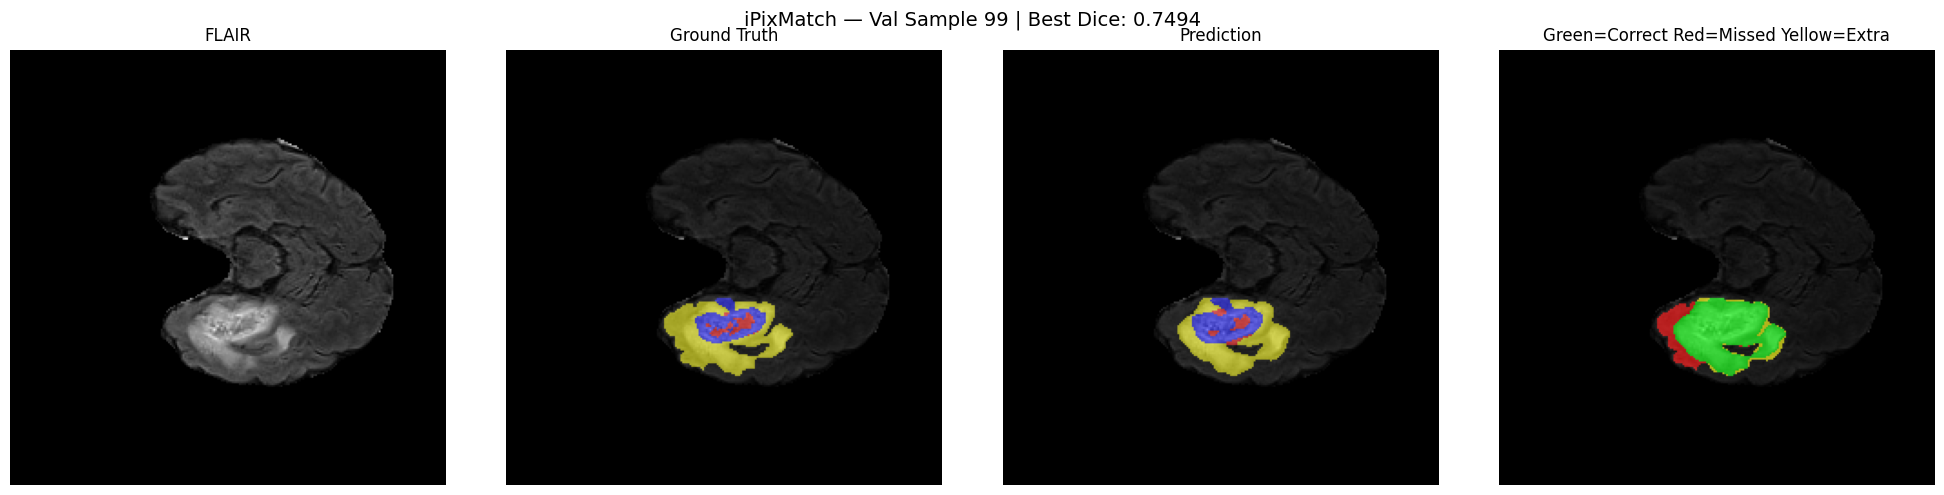


Idx 101 | pred max=1.000 mean=0.0120
  GT   WT:200 TC:1354 ET:497
  Pred WT:465 TC:1123 ET:593


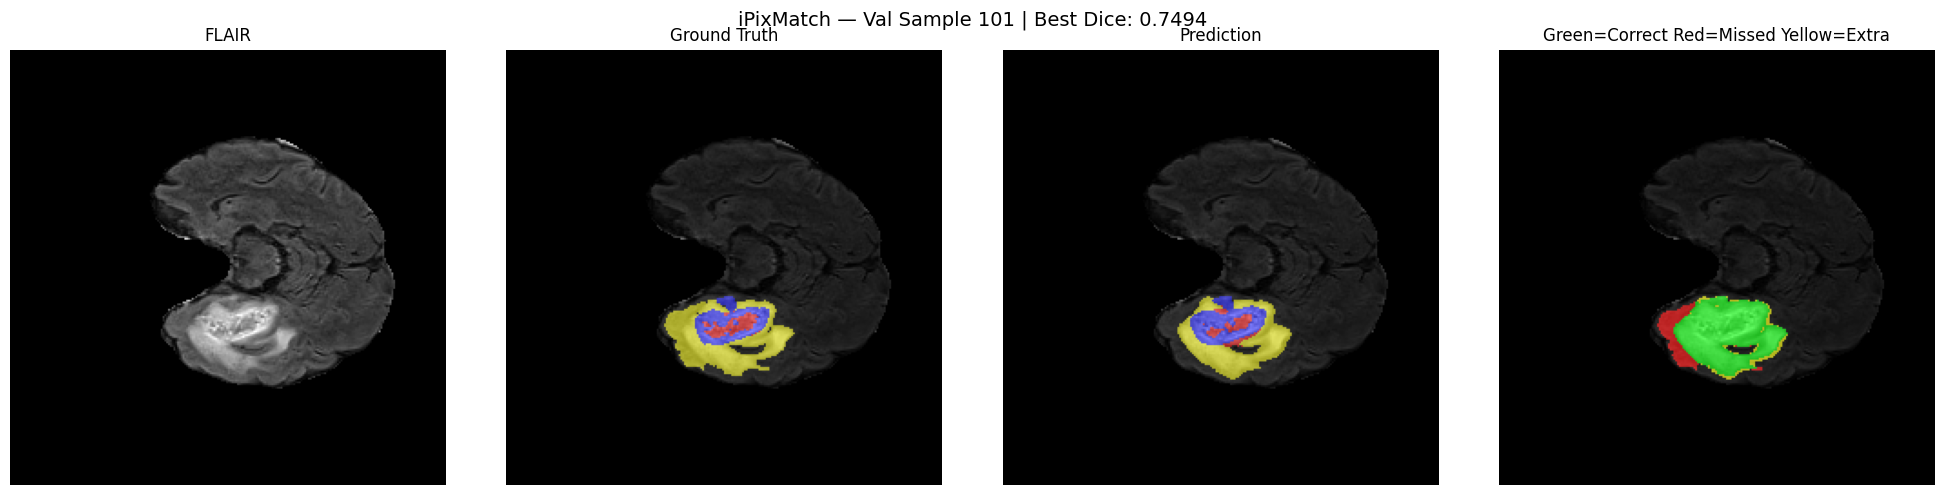


Idx 102 | pred max=1.000 mean=0.0124
  GT   WT:229 TC:1280 ET:521
  Pred WT:487 TC:1152 ET:643


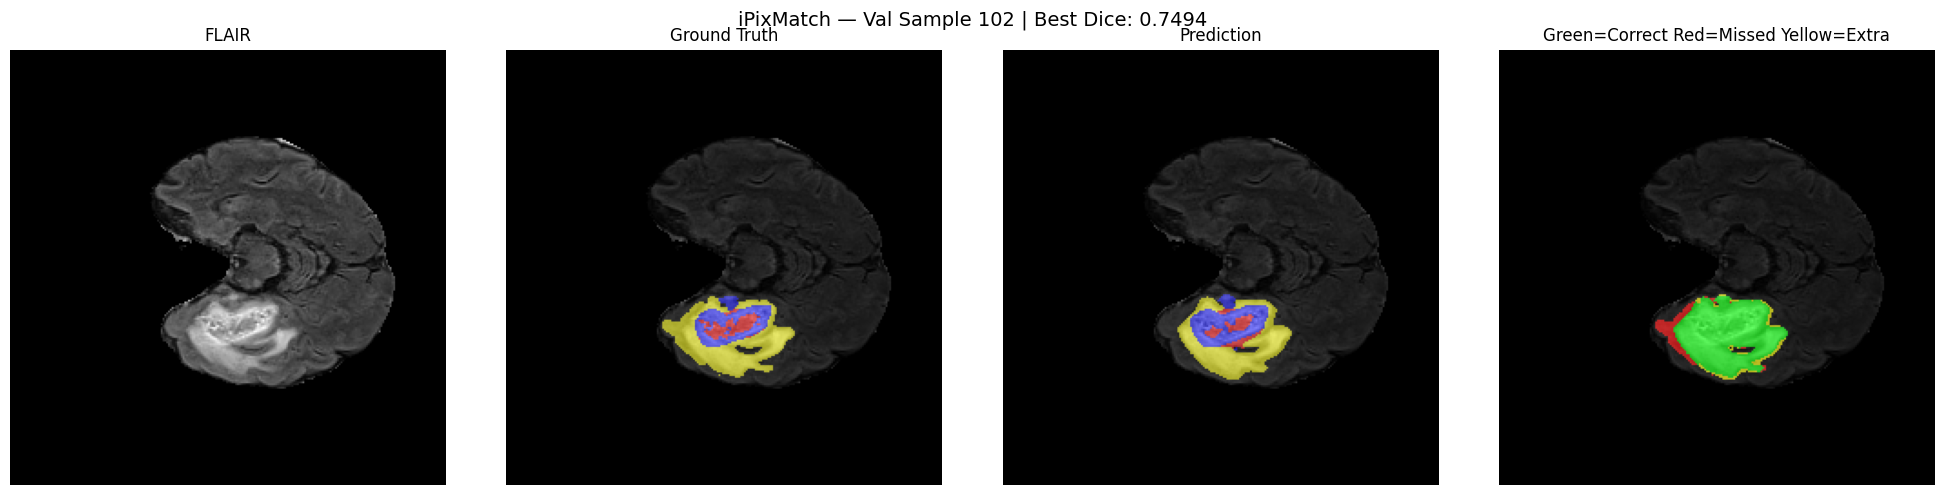

In [18]:
import matplotlib.pyplot as plt

good_indices = []
for idx in range(len(val_ds)):
    gt = val_ds[idx]["label"].numpy()
    if gt[0].sum() > 100 and gt[1].sum() > 100 and gt[2].sum() > 100:
        good_indices.append(idx)
    if len(good_indices) == 3:
        break

print("Good indices:", good_indices)
teacher.eval()

for idx in good_indices:
    sample   = val_ds[idx]
    img      = sample["image"].unsqueeze(0).to(DEVICE)
    flair    = sample["image"][0].numpy()
    gt       = sample["label"].numpy()

    with torch.no_grad():
        pred = torch.sigmoid(teacher(img)[0]).cpu().numpy()[0]

    pred_bin = (pred > 0.3).astype(np.uint8)

    print(f"\nIdx {idx} | pred max={pred.max():.3f} mean={pred.mean():.4f}")
    print(f"  GT   WT:{gt[0].sum():.0f} TC:{gt[1].sum():.0f} ET:{gt[2].sum():.0f}")
    print(f"  Pred WT:{pred_bin[0].sum()} TC:{pred_bin[1].sum()} ET:{pred_bin[2].sum()}")

    gt_overlay   = np.zeros((*flair.shape, 3))
    pred_overlay = np.zeros((*flair.shape, 3))
    diff         = np.zeros((*flair.shape, 3))

    gt_overlay[gt[0]==1]=[1,0,0]; gt_overlay[gt[1]==1]=[1,1,0]; gt_overlay[gt[2]==1]=[0,0,1]
    pred_overlay[pred_bin[0]==1]=[1,0,0]
    pred_overlay[pred_bin[1]==1]=[1,1,0]
    pred_overlay[pred_bin[2]==1]=[0,0,1]

    gt_union   = gt.sum(0) > 0
    pred_union = pred_bin.sum(0) > 0
    diff[np.logical_and(gt_union,  pred_union)]  = [0,1,0]
    diff[np.logical_and(gt_union,  ~pred_union)] = [1,0,0]
    diff[np.logical_and(~gt_union, pred_union)]  = [1,1,0]

    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    axes[0].imshow(flair, cmap="gray"); axes[0].set_title("FLAIR"); axes[0].axis("off")
    axes[1].imshow(flair, cmap="gray"); axes[1].imshow(gt_overlay,   alpha=0.5)
    axes[1].set_title("Ground Truth"); axes[1].axis("off")
    axes[2].imshow(flair, cmap="gray"); axes[2].imshow(pred_overlay, alpha=0.5)
    axes[2].set_title("Prediction"); axes[2].axis("off")
    axes[3].imshow(flair, cmap="gray"); axes[3].imshow(diff,         alpha=0.6)
    axes[3].set_title("Green=Correct Red=Missed Yellow=Extra"); axes[3].axis("off")
    plt.suptitle(f"iPixMatch — Val Sample {idx} | Best Dice: {best_dice:.4f}",
                 fontsize=14)
    plt.tight_layout(); plt.show()
